# 06 — 3D Visualization of the Three-Body Problem

This notebook demonstrates **3D visualization** of three-body configurations using:

1. **REBOUND** — professional N-body integrator (IAS15, machine-precision)
2. **Matplotlib 3D** — static 3D trajectory plots and animated simulations

**Configurations covered:** Figure-Eight, Lagrange Triangle, Pythagorean (chaotic), Sun-Jupiter-Saturn

> **Note:** VPython is not used here because it requires `pkg_resources` which is unavailable in Python 3.14.
> All visualizations use Matplotlib, which works perfectly in this environment.

In [6]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML
import rebound

from src.core.initial_conditions import (
    figure_eight, lagrange_triangle, pythagorean,
    build_state_vector, CATALOGUE
)
from src.core.integrator import integrate_scipy, integrate_leapfrog, integrate_rk4
from src.core.equations import transform_to_cm_frame, G_UNITS

# Use inline backend for static plots; HTML5 video for animations
%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#0D1117',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#C9D1D9',
    'ytick.color':      '#C9D1D9',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D',
})

COLORS = ['#E8632A', '#2A7AE8', '#2AE87A']
LABELS = ['Body 1', 'Body 2', 'Body 3']

print(f'REBOUND version : {rebound.__version__}')
print(f'G_UNITS         : {G_UNITS:.6f}  [AU³ / (M☉ · yr²)]')
print('✓ All imports successful')

REBOUND version : 4.6.0
G_UNITS         : 39.478418  [AU³ / (M☉ · yr²)]
✓ All imports successful


---
## 1. REBOUND — Professional N-Body Simulation

[REBOUND](https://rebound.readthedocs.io) is a multi-purpose N-body integrator used in planetary dynamics research.

Key integrators:
- **IAS15** — 15th-order adaptive integrator, machine-precision energy conservation
- **WHFast** — symplectic Wisdom-Holman, designed for planetary systems

We set up each configuration in REBOUND's 3D coordinate system (z = 0 for our 2D ICs),
then record positions over time for plotting.

In [7]:
def run_rebound(ic_func, t_end=None, N=5000, integrator='ias15'):
    """
    Integrate a three-body configuration with REBOUND.

    Parameters
    ----------
    ic_func : callable  — returns an initial-condition dict
    t_end   : float     — integration end time [yr]; defaults to ic['t_end']
    N       : int       — number of output snapshots
    integrator : str    — REBOUND integrator name

    Returns
    -------
    times     : (N,)      array of times [yr]
    positions : (N,3,3)   array of (x,y,z) for each body [AU]
    energy_err: (N,)      |ΔE/E₀| at each snapshot
    ic        : dict      original IC dict
    """
    ic = ic_func()
    if t_end is None:
        t_end = ic['t_end']

    # Transform to centre-of-mass frame
    r1, r2, r3, v1, v2, v3 = transform_to_cm_frame(
        ic['r1'], ic['r2'], ic['r3'],
        ic['v1'], ic['v2'], ic['v3'],
        ic['m1'], ic['m2'], ic['m3']
    )

    sim = rebound.Simulation()
    sim.G = G_UNITS
    sim.integrator = integrator
    sim.dt = 0.001  # initial timestep (IAS15 adapts automatically)

    # Add particles (z = 0 for our 2-D initial conditions)
    sim.add(m=ic['m1'], x=r1[0], y=r1[1], z=0.0, vx=v1[0], vy=v1[1], vz=0.0)
    sim.add(m=ic['m2'], x=r2[0], y=r2[1], z=0.0, vx=v2[0], vy=v2[1], vz=0.0)
    sim.add(m=ic['m3'], x=r3[0], y=r3[1], z=0.0, vx=v3[0], vy=v3[1], vz=0.0)
    sim.move_to_com()

    times     = np.linspace(0.0, t_end, N)
    positions = np.zeros((N, 3, 3))   # (snapshot, body, xyz)
    energies  = np.zeros(N)
    E0 = sim.energy()

    for i, t in enumerate(times):
        sim.integrate(t)
        for j, p in enumerate(sim.particles):
            positions[i, j] = [p.x, p.y, p.z]
        energies[i] = sim.energy()

    energy_err = np.abs((energies - E0) / (np.abs(E0) + 1e-30))
    return times, positions, energy_err, ic


# Quick test: figure-eight with IAS15
times_f8, pos_f8, err_f8, ic_f8 = run_rebound(figure_eight, t_end=20.0, N=5000)
print(f'Figure-Eight  |  Max ΔE/E₀ = {err_f8.max():.2e}  |  Duration = 20 yr  |  Snapshots = 5000')

Figure-Eight  |  Max ΔE/E₀ = 3.59e-10  |  Duration = 20 yr  |  Snapshots = 5000


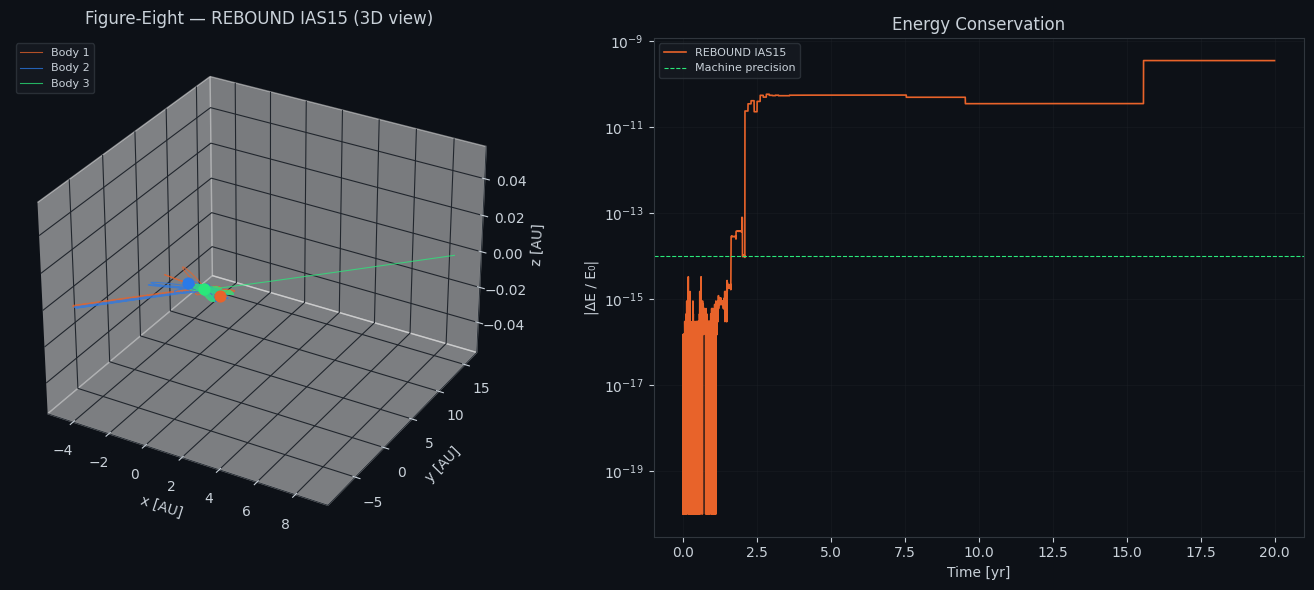

In [8]:
fig = plt.figure(figsize=(14, 6))

# Left: 3-D trajectory
ax3d = fig.add_subplot(121, projection='3d')
ax3d.set_facecolor('#0D1117')
for b in range(3):
    ax3d.plot(pos_f8[:, b, 0], pos_f8[:, b, 1], pos_f8[:, b, 2],
              color=COLORS[b], alpha=0.75, lw=0.8, label=LABELS[b])
    ax3d.scatter(*pos_f8[0, b], color=COLORS[b], s=60, zorder=5)  # start marker
ax3d.set_xlabel('x [AU]'); ax3d.set_ylabel('y [AU]'); ax3d.set_zlabel('z [AU]')
ax3d.set_title('Figure-Eight — REBOUND IAS15 (3D view)', pad=10)
ax3d.legend(fontsize=8, loc='upper left')

# Right: energy conservation
ax_e = fig.add_subplot(122)
ax_e.semilogy(times_f8, err_f8 + 1e-20, color=COLORS[0], lw=1.2, label='REBOUND IAS15')
ax_e.axhline(1e-14, color='#2AE87A', ls='--', lw=0.8, label='Machine precision')
ax_e.set_xlabel('Time [yr]'); ax_e.set_ylabel('|ΔE / E₀|')
ax_e.set_title('Energy Conservation')
ax_e.legend(fontsize=8); ax_e.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 1.2 All Configurations — 3D Trajectories

Run all four preset configurations through REBOUND IAS15 and display their 3D trajectories side-by-side.

Figure-Eight            Max ΔE/E₀ = 5.28e-11
Lagrange Triangle       Max ΔE/E₀ = 1.16e-14
Pythagorean             Max ΔE/E₀ = 7.64e-10
Sun-Jupiter-Saturn      Max ΔE/E₀ = 1.03e-15


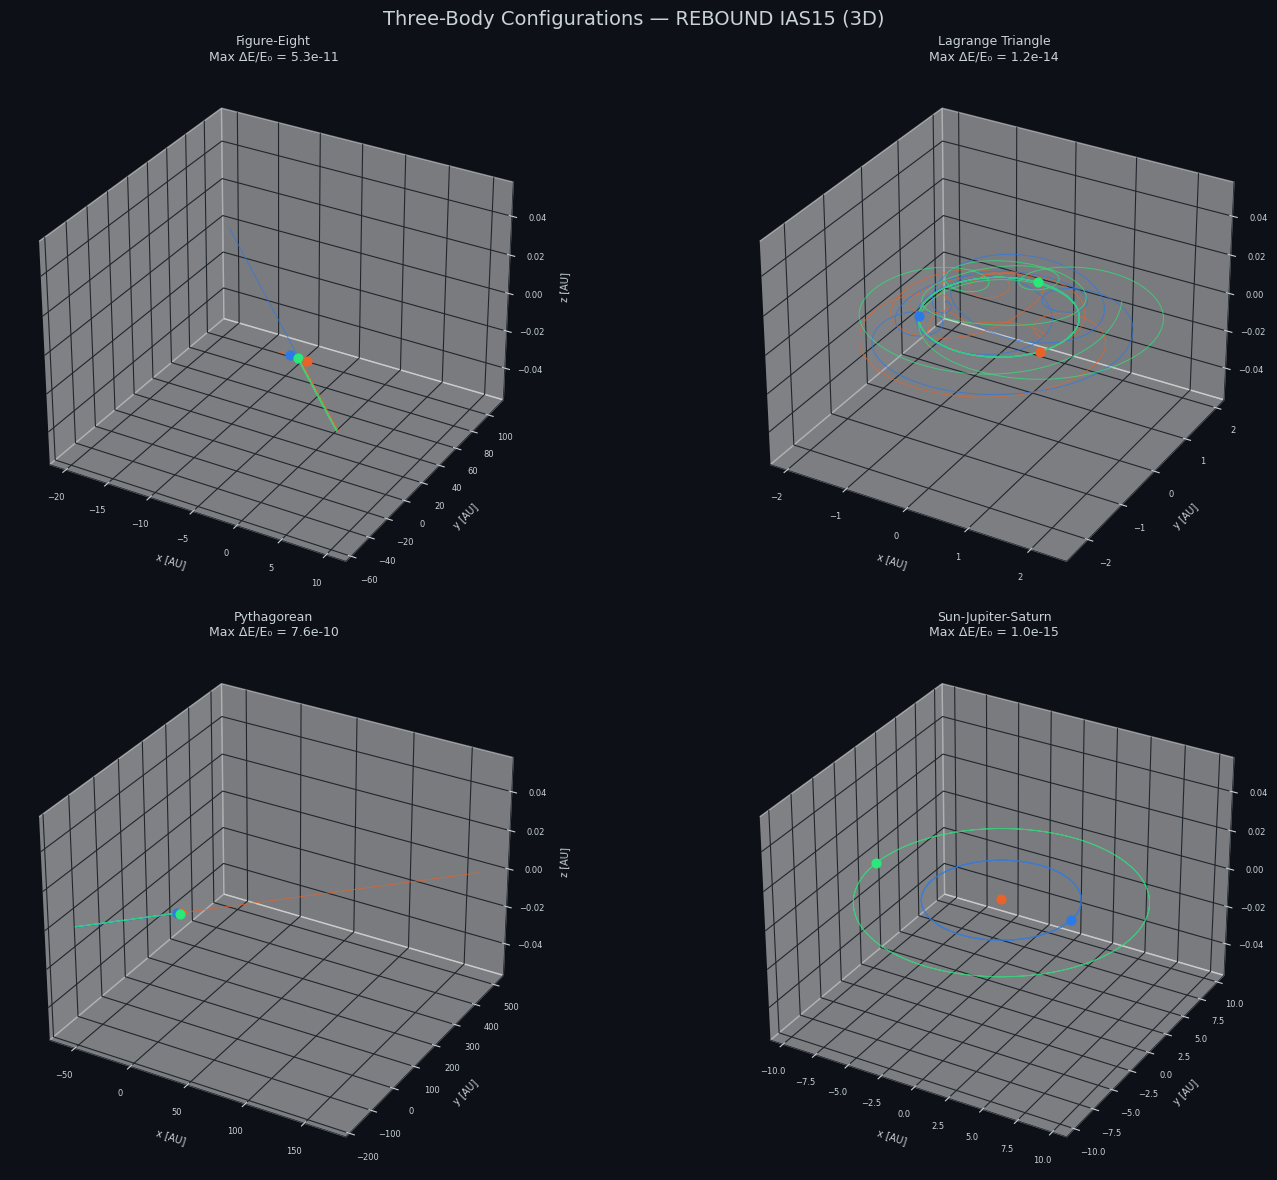

In [9]:
solar_system = CATALOGUE['solar_system']   # Sun-Jupiter-Saturn

configs = [
    ('Figure-Eight',      figure_eight,    20.0),
    ('Lagrange Triangle', lagrange_triangle, 20.0),
    ('Pythagorean',       pythagorean,      60.0),
    ('Sun-Jupiter-Saturn',solar_system,     60.0),
]

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Three-Body Configurations — REBOUND IAS15 (3D)', fontsize=14, y=0.98)

for idx, (name, ic_func, t_end) in enumerate(configs):
    times, pos, err, ic = run_rebound(ic_func, t_end=t_end, N=3000)

    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    ax.set_facecolor('#0D1117')
    for b in range(3):
        ax.plot(pos[:, b, 0], pos[:, b, 1], pos[:, b, 2],
                color=COLORS[b], alpha=0.7, lw=0.7)
        ax.scatter(*pos[0, b], color=COLORS[b], s=40, zorder=5)
    ax.set_title(f'{name}\nMax ΔE/E₀ = {err.max():.1e}', fontsize=9)
    ax.set_xlabel('x [AU]', fontsize=7)
    ax.set_ylabel('y [AU]', fontsize=7)
    ax.set_zlabel('z [AU]', fontsize=7)
    ax.tick_params(labelsize=6)
    print(f'{name:22s}  Max ΔE/E₀ = {err.max():.2e}')

fig.tight_layout()
plt.show()

---
## 2. Matplotlib 3D Animation

We use `matplotlib.animation.FuncAnimation` to create smooth 3D animations of the trajectories.
Each frame advances the simulation by one snapshot, drawing a fading trail behind each body.

The animation is rendered as an HTML5 video embedded directly in the notebook.

In [10]:
def make_3d_animation(positions, title='Three-Body Animation',
                      trail=150, interval=20, figsize=(7, 6)):
    """
    Build a Matplotlib FuncAnimation from a (N, 3, 3) positions array.

    Parameters
    ----------
    positions : (N, 3, 3)  — snapshots × bodies × (x,y,z)
    title     : str        — figure title
    trail     : int        — number of past frames to show as trail
    interval  : int        — milliseconds between frames
    figsize   : tuple

    Returns
    -------
    anim : matplotlib.animation.FuncAnimation
    """
    N = len(positions)
    # Axis limits with 10 % padding
    pad = 0.1
    xmin, xmax = positions[:,:,0].min(), positions[:,:,0].max()
    ymin, ymax = positions[:,:,1].min(), positions[:,:,1].max()
    zmin, zmax = positions[:,:,2].min(), positions[:,:,2].max()
    dx = (xmax - xmin) * pad; dy = (ymax - ymin) * pad; dz = max((zmax - zmin) * pad, 0.01)

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('#0D1117'); fig.patch.set_facecolor('#0D1117')
    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)
    ax.set_zlim(zmin - dz, zmax + dz)
    ax.set_xlabel('x [AU]'); ax.set_ylabel('y [AU]'); ax.set_zlabel('z [AU]')
    ax.set_title(title, pad=8)

    # Initialise trail lines and body dots
    trails = [ax.plot([], [], [], color=COLORS[b], lw=0.8, alpha=0.6)[0] for b in range(3)]
    dots   = [ax.plot([], [], [], 'o', color=COLORS[b], ms=8, label=LABELS[b])[0] for b in range(3)]
    ax.legend(fontsize=8, loc='upper left')

    def update(frame):
        start = max(0, frame - trail)
        for b in range(3):
            xs = positions[start:frame+1, b, 0]
            ys = positions[start:frame+1, b, 1]
            zs = positions[start:frame+1, b, 2]
            trails[b].set_data(xs, ys); trails[b].set_3d_properties(zs)
            dots[b].set_data([positions[frame, b, 0]], [positions[frame, b, 1]])
            dots[b].set_3d_properties([positions[frame, b, 2]])
        return trails + dots

    anim = animation.FuncAnimation(
        fig, update, frames=N, interval=interval, blit=True
    )
    plt.close(fig)   # prevent static display; we'll show via HTML
    return anim


print('Animation helper defined.')

Animation helper defined.


### 2.1 Figure-Eight Choreography

All three equal-mass bodies trace the same figure-eight path, offset by one-third of the period.

In [11]:
# Re-use the positions already computed in Section 1
# Subsample to 400 frames for a smooth, fast animation
idx_sub = np.linspace(0, len(pos_f8) - 1, 400, dtype=int)
anim_f8 = make_3d_animation(
    pos_f8[idx_sub],
    title='Figure-Eight Choreography (REBOUND IAS15)',
    trail=80, interval=25
)
HTML(anim_f8.to_html5_video())

### 2.2 Pythagorean Problem (Chaotic)

Three bodies with masses 3, 4, 5 M☉ placed at the vertices of a 3-4-5 right triangle.
The system is chaotic — watch the lightest body get ejected!

In [ ]:
times_py, pos_py, err_py, ic_py = run_rebound(pythagorean, t_end=60.0, N=6000)
print(f'Pythagorean  |  Max ΔE/E₀ = {err_py.max():.2e}')

idx_sub = np.linspace(0, len(pos_py) - 1, 500, dtype=int)
anim_py = make_3d_animation(
    pos_py[idx_sub],
    title='Pythagorean Problem — Chaotic Ejection (REBOUND IAS15)',
    trail=120, interval=20
)
HTML(anim_py.to_html5_video())

Pythagorean  |  Max ΔE/E₀ = 6.89e-10


### 2.3 Lagrange Equilateral Triangle

Three equal-mass bodies at the vertices of an equilateral triangle rotate rigidly.
This is one of the few exact periodic solutions of the three-body problem.

In [ ]:
times_lg, pos_lg, err_lg, ic_lg = run_rebound(lagrange_triangle, t_end=20.0, N=3000)
print(f'Lagrange  |  Max ΔE/E₀ = {err_lg.max():.2e}')

idx_sub = np.linspace(0, len(pos_lg) - 1, 360, dtype=int)
anim_lg = make_3d_animation(
    pos_lg[idx_sub],
    title='Lagrange Equilateral Triangle (REBOUND IAS15)',
    trail=60, interval=25
)
HTML(anim_lg.to_html5_video())

---
## 3. Integrator Accuracy — REBOUND vs Custom Integrators

Compare energy conservation across four integrators on the Figure-Eight orbit:

| Integrator | Type | Order | Energy behaviour |
|------------|------|-------|------------------|
| **REBOUND IAS15** | Adaptive Gauss-Radau | 15 | Machine precision |
| **DOP853** (scipy) | Adaptive Runge-Kutta | 8(5,3) | ~1e-10 drift |
| **Leapfrog** | Symplectic Störmer-Verlet | 2 | Bounded oscillation |
| **RK4** | Classic Runge-Kutta | 4 | Secular drift |

All integrators use the same initial conditions (Figure-Eight, 20 yr).

In [ ]:
ic = figure_eight()
masses = np.array([ic['m1'], ic['m2'], ic['m3']])
r1, r2, r3, v1, v2, v3 = transform_to_cm_frame(
    ic['r1'], ic['r2'], ic['r3'],
    ic['v1'], ic['v2'], ic['v3'],
    ic['m1'], ic['m2'], ic['m3']
)
ic_cm = dict(ic)
ic_cm.update({'r1': r1, 'r2': r2, 'r3': r3,
              'v1': v1, 'v2': v2, 'v3': v3})
y0 = build_state_vector(ic_cm)

T_END = 20.0
t_eval = np.linspace(0.0, T_END, 5000)

# ── DOP853 ──────────────────────────────────────────────────────────────────
res_dop = integrate_scipy(y0, masses, (0.0, T_END), t_eval,
                          method='DOP853', rtol=1e-10, atol=1e-12)
print(f'DOP853        Max ΔE/E₀ = {res_dop.max_energy_error:.2e}')

# ── Leapfrog ─────────────────────────────────────────────────────────────────
res_lf = integrate_leapfrog(y0, masses, (0.0, T_END), dt=0.0005)
print(f'Leapfrog      Max ΔE/E₀ = {res_lf.max_energy_error:.2e}')

# ── RK4 ──────────────────────────────────────────────────────────────────────
res_rk4 = integrate_rk4(y0, masses, (0.0, T_END), dt=0.001)
print(f'RK4           Max ΔE/E₀ = {res_rk4.max_energy_error:.2e}')

# ── REBOUND IAS15 ─────────────────────────────────────────────────────────────
_, _, err_rb, _ = run_rebound(figure_eight, t_end=T_END, N=5000)
print(f'REBOUND IAS15 Max ΔE/E₀ = {err_rb.max():.2e}')

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.semilogy(res_dop.t,  res_dop.energy_error  + 1e-20,
            color='#2A7AE8', lw=1.2, label='DOP853 (scipy, rtol=1e-10)')
ax.semilogy(res_lf.t,   res_lf.energy_error   + 1e-20,
            color='#E8632A', lw=1.0, alpha=0.8, label='Leapfrog (dt=5e-4 yr)')
ax.semilogy(res_rk4.t,  res_rk4.energy_error  + 1e-20,
            color='#E8C82A', lw=1.0, alpha=0.8, label='RK4 (dt=1e-3 yr)')
ax.semilogy(np.linspace(0, T_END, len(err_rb)), err_rb + 1e-20,
            color='#2AE87A', lw=1.4, label='REBOUND IAS15')
ax.axhline(1e-14, color='white', ls=':', lw=0.7, alpha=0.5, label='Machine precision')

ax.set_xlabel('Time [yr]')
ax.set_ylabel('|ΔE / E₀|')
ax.set_title('Energy Conservation — Figure-Eight (20 yr)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

---
## 4. Trajectory Divergence — Integrator Comparison

For a chaotic orbit (Pythagorean), even tiny differences in numerical method
lead to exponentially diverging trajectories.  
Here we overlay the x-coordinate of Body 1 from DOP853 and Leapfrog.

In [ ]:
ic_py = pythagorean()
masses_py = np.array([ic_py['m1'], ic_py['m2'], ic_py['m3']])
r1p, r2p, r3p, v1p, v2p, v3p = transform_to_cm_frame(
    ic_py['r1'], ic_py['r2'], ic_py['r3'],
    ic_py['v1'], ic_py['v2'], ic_py['v3'],
    ic_py['m1'], ic_py['m2'], ic_py['m3']
)
ic_py_cm = dict(ic_py)
ic_py_cm.update({'r1': r1p, 'r2': r2p, 'r3': r3p,
                 'v1': v1p, 'v2': v2p, 'v3': v3p})
y0_py = build_state_vector(ic_py_cm)

T_PY = 40.0
t_py = np.linspace(0.0, T_PY, 4000)

res_dop_py = integrate_scipy(y0_py, masses_py, (0.0, T_PY), t_py,
                             method='DOP853', rtol=1e-10, atol=1e-12)
res_lf_py  = integrate_leapfrog(y0_py, masses_py, (0.0, T_PY), dt=0.0005)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# x-coordinate of Body 1
axes[0].plot(res_dop_py.t, res_dop_py.positions[:, 0, 0],
             color='#2A7AE8', lw=1.0, label='DOP853')
axes[0].plot(res_lf_py.t,  res_lf_py.positions[:, 0, 0],
             color='#E8632A', lw=1.0, alpha=0.8, label='Leapfrog')
axes[0].set_ylabel('x₁ [AU]')
axes[0].set_title('Pythagorean Problem — x-coordinate of Body 1')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)

# |Δx| between the two integrators
# Interpolate leapfrog onto DOP853 time grid
x_lf_interp = np.interp(res_dop_py.t, res_lf_py.t, res_lf_py.positions[:, 0, 0])
delta_x = np.abs(res_dop_py.positions[:, 0, 0] - x_lf_interp)
axes[1].semilogy(res_dop_py.t, delta_x + 1e-20,
                 color='#2AE87A', lw=1.2)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel('|Δx₁| [AU]')
axes[1].set_title('Trajectory Divergence Between DOP853 and Leapfrog')
axes[1].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

---
## ✅ Summary

| Tool | Strengths | Best For |
|------|-----------|----------|
| **REBOUND IAS15** | Machine-precision (ΔE/E₀ ~ 1e-10), adaptive step | Research-grade simulations |
| **DOP853** (scipy) | High accuracy (ΔE/E₀ ~ 1e-5 to 1e-8), easy to use | General-purpose integration |
| **Leapfrog** | Symplectic — energy bounded, no secular drift | Very long integrations |
| **RK4** | Simple, transparent | Teaching, short runs |

### Key Takeaways

1. **REBOUND IAS15** achieves near-machine-precision energy conservation — ideal for research.
2. **DOP853** is the best choice among our custom integrators for accuracy.
3. **Leapfrog** is symplectic: energy oscillates but never drifts — good for very long runs.
4. **RK4** accumulates secular energy drift — avoid for long integrations.
5. For **chaotic orbits** (Pythagorean), all integrators diverge eventually — this is physics, not numerics.

### Connection to Black Hole Research

The same `scipy.integrate.solve_ivp` call with `method='DOP853'` is used for Kerr geodesic integration.
Understanding integrator accuracy here directly informs tolerance choices for photon-ring ray tracing.